In [ ]:
# Check R version
R.version

# Check if you have Rtools installed (needed for compilation on Windows)
Sys.which("make")

# Try to install a simple package that requires compilation
install.packages("lattice")

# Check which packages failed
.packages(all.available = TRUE)

# Try installing ggplot2 with explicit type
install.packages("ggplot2", type = "binary", dependencies = TRUE)

# Check for broken packages
find.package(package = "ggplot2", lib.loc = NULL, quiet = FALSE)

In [ ]:
remove.packages("gtable")
install.packages("gtable")

In [ ]:
install.packages(c("vegan", "ggrepel", "NADA2", "tidyverse"))
# !diagnostics suppress=TRUE

In [ ]:
library(vegan)
#library(NADA2)
library(ggplot2)
library(ggrepel)
library(tidyverse)

In [1]:
df <- read.csv("C:/Users/leila/Dropbox/MayoWetlands/wetland_alldata_2025_reduced.csv") #nolint 
# Remove Upland class
df <- df[df$Class != "UL", ]

names(df)

[1] "SiteID"                      "Class"                      
  [3] "class_num"                   "Date.Sampled"               
  [5] "Time.Sampled"                "NDVI_amp_harmonic"          
  [7] "NDVI_phase_harmonic"         "TCW_p10"                    
  [9] "TCW_p40"                     "TCW_p80"                    
 [11] "TCW_p90"                     "SWI_median"                 
 [13] "SWI_stdev"                   "SWI_p90"                    
 [15] "log_DDG_mean"                "log_DDG_median"             
 [17] "log_DDS_min"                 "log_DDS_max"                
 [19] "log_DDS_stdev"               "log_MCA_stdev"              
 [21] "log_MCA_p90"                 "log_VDCN_median"            
 [23] "log_VDCN_mean"               "log_VDCN_min"               
 [25] "log_VDCN_max"                "log_VDCN_stdev"             
 [27] "HOFD_median"                 "HOFD_mean"                  
 [29] "HOFD_min"                    "HOFD_max"                   
 [31] "HOFD_stdev"                  "HOFD_p90"                   
 [33] "VOFD_mean"                   "VOFD_min"                   
 [35] "VOFD_max"                    "VOFD_stdev"                 
 [37] "VOFD_p90"                    "Geom_mode_9"                
 [39] "Geom_mode_10"                "NDVI_MAX"                   
 [41] "NDVI_STD"                    "NDVI_PCT90"                 
 [43] "NDGVI_MIN"                   "NDGVI_STD"                  
 [45] "SR_MIN"                      "SR_MAX"                     
 [47] "SR_RANGE"                    "SR_MEAN"                    
 [49] "SR_STD"                      "SR_MEDIAN"                  
 [51] "SR_PCT90"                    "RED_mean"                   
 [53] "RED_median"                  "RED_min"                    
 [55] "GREEN_max"                   "GREEN_min"                  
 [57] "GREEN_p25"                   "REDEDGE_min"                
 [59] "REDEDGE_p25"                 "NIR_mean"                   
 [61] "NIR_median"                  "NIR_max"                    
 [63] "NIR_min"                     "NIR_p25"                    
 [65] "NIR_75"                      "NIR_p95"                    
 [67] "NIR_iqr"                     "NIR_stdev"                  
 [69] "average_veg_height"          "median_veg_height"          
 [71] "max_veg_height"              "min_veg_height"             
 [73] "stddev_veg_height"           "P95_veg_height"             
 [75] "P75_veg_height"              "P25_veg_height"             
 [77] "IQR_veg_height"              "CanopyCover1m"              
 [79] "CanopyCover2m"               "stem_density"               
 [81] "WTP_StDev"                   "WTP_max"                    
 [83] "WTP_min"                     "WTP_median"                 
 [85] "WTP_stdev"                   "WTP_range"                  
 [87] "Recharge"                    "Discharge"                  
 [89] "unknown_hydro"               "VHG_average"                
 [91] "VHG_median"                  "VHG_max"                    
 [93] "VHG_min"                     "VHG_stdev"                  
 [95] "VHG_range"                   "small_tree"                 
 [97] "shrub"                       "graminoid"                  
 [99] "moss"                        "lichen"                     
[101] "dom_tall_tree_none"          "dom_small_tree_will"        
[103] "dom_small_tree_spruce"       "dom_small_tree_none"        
[105] "dom_graminoid_grass"         "equisetum_dom"              
[107] "Al"                          "As"                         
[109] "Ba"                          "Ca"                         
[111] "Cu"                          "F"                          
[113] "Fe"                          "Li"                         
[115] "Mg"                          "Mn"                         
[117] "Mo"                          "K"                          
[119] "Si"                          "Na"                         
[121] "Sr"                          "S"   

In [ ]:
# drop rows with NAs
# This will drop the Marsh and Bog columns that do not have all the hydro data 
#df <- na.omit(df)


In [ ]:
#df <- df[!grepl("^ELA", df$SiteID), ]


In [ ]:

#df <- df[, !names(df) %in% c("SR_MIN", "SR_MAX")]

In [28]:
# ============================================================================
# STEP 2: Define variable groups (column ranges)
# ============================================================================

# Vegetation UAV ALL (predictor RDA1)
veg_start <- which(names(df) == "REDEDGE_min")  
veg_end   <- which(names(df) == "stem_density")      
veg_cols <- names(df)[veg_start:veg_end]

# Veg - UAV structure only
struct_start <- which(names(df)=="average_veg_height")
struct_end   <- which(names(df) == "stem_density")
struct_cols  <- names(df)[struct_start:struct_end]

# Veg - UAV MS only
ms_start <- which(names(df)=="REDEDGE_min")
ms_end   <- which(names(df) == "GREEN_stdev")
ms_cols <- names(df)[ms_start:ms_end]

# Field veg 
field_start <- which(names(df)=="small_tree")
field_end   <- which(names(df)=="equisetum_dom")
field_cols <- names(df)[field_start:field_end]

# Hydrology (predictors for RDA1, response for RDA2)
hydro_start <- which(names(df) == "WTP_stdev")      # or your first hydro col
hydro_end   <- which(names(df) == "VHG_range")  # adjust as needed
hydro_cols <- names(df)[hydro_start:hydro_end]

# Chemistry (predictors for RDA1, response for RDA2)
# NOTE: Chemistry is already u-score transformed in the reduced CSV
chem_start <- which(names(df) == "Al")
chem_end   <- which(names(df) == "ORPmV")
chem_cols <- names(df)[chem_start:chem_end]

# Topography (predictors for RDA2)
topo_start <- which(names(df) == "SWI_median")
topo_end   <- which(names(df) == "Geom_mode_10")
topo_cols <- names(df)[topo_start:topo_end]

# UAV structure & indices (for reference/additional analysis if needed)
#uav_veg_cols <- c("median_veg_height", "average_veg_height", "NDVI_MEAN", "NDGVI_MEAN")  # adjust

In [117]:
print(ms_cols)

 [1] "REDEDGE_min" "SR_STD"      "RED_min"     "SR_RANGE"    "NIR_min"    
 [6] "SR_MAX"      "SR_PCT90"    "SR_MEAN"     "REDEDGE_p25" "NIR_median" 


In [118]:
print(hydro_cols)

 [1] "WTP_stdev"     "WTP_range"     "Recharge"      "Discharge"    
 [5] "unknown_hydro" "VHG_average"   "VHG_median"    "VHG_max"      
 [9] "VHG_min"       "VHG_stdev"     "VHG_range"    


In [193]:
print(ms_cols)

 [1] "NDVI_MIN"     "NDVI_MAX"     "NDVI_STD"     "NDVI_PCT90"   "NDGVI_MIN"   
 [6] "NDGVI_MEAN"   "NDGVI_STD"    "NDGVI_MEDIAN" "NDGVI_PCT90"  "SR_RANGE"    
[11] "SR_MEAN"      "SR_STD"      


In [29]:
# ============================================================================
# STEP 4: Prepare Response Data (Chemistry + Hydrology)
# ============================================================================

# Remove VHG and WTP columns from hydro_cols
hydro_cols <- hydro_cols[!grepl("VHG|WTP", hydro_cols)]

# Get hydrology data
hydro_data <- df[, hydro_cols]
rownames(hydro_data) <- df$SiteID

# Get chemistry data (already u-score transformed in the CSV)
chem_data <- df[, chem_cols]
rownames(chem_data) <- df$SiteID

# Combine chemistry (u-score dataframe) with hydrology data as RESPONSE
response <- cbind(chem_data, hydro_data)
rownames(response) <- df$SiteID

# ============================================================================
# STEP 5: Prepare Predictor Data (Vegetation)
# ============================================================================

predictors <- df[, c(ms_cols, struct_cols)]
rownames(predictors) <- df$SiteID

# ============================================================================
# STEP 6: Fit RDA1 (FLIPPED)
# ============================================================================
rda1 <- rda(response ~ ., data = predictors)
summary(rda1)




Call:
rda(formula = response ~ REDEDGE_min + SR_STD + RED_min + SR_RANGE +      NIR_min + SR_MAX + SR_PCT90 + SR_MEAN + REDEDGE_p25 + NIR_median +      SR_MEDIAN + NIR_p25 + NDVI_MAX + NIR_max + GREEN_min + GREEN_p25 +      SR_MIN + NDVI_PCT90 + NDVI_RANGE + GREEN_stdev + average_veg_height +      stddev_veg_height + P75_veg_height + P95_veg_height + IQR_veg_height +      CanopyCover1m + max_veg_height + stem_density, data = predictors) 

Partitioning of variance:
              Inertia Proportion
Total           82167     1.0000
Constrained     65709     0.7997
Unconstrained   16458     0.2003

Eigenvalues, and their contribution to the variance 

Importance of components:
                           RDA1      RDA2      RDA3      RDA4      RDA5
Eigenvalue            4.332e+04 9831.6914 4.217e+03 3.318e+03 1824.1638
Proportion Explained  5.273e-01    0.1197 5.132e-02 4.038e-02    0.0222
Cumulative Proportion 5.273e-01    0.6469 6.982e-01 7.386e-01    0.7608
                           RD

In [12]:
vif_values <- vif.cca(rda1)
print(vif_values)

# Sort VIF values to see highest multicollinearity first
vif_sorted <- sort(vif_values, decreasing = TRUE)
print(vif_sorted)

# Identify variables with high VIF (common threshold is VIF > 10)
high_vif <- vif_values[vif_values > 10]
print("Variables with VIF > 10:")
print(high_vif)

       REDEDGE_min             SR_STD            RED_min           SR_RANGE 
      4.389658e+11       1.183350e+13       7.198910e+12       2.910541e+19 
           NIR_min             SR_MAX           SR_PCT90            SR_MEAN 
      4.206871e+10       2.905069e+19       1.004858e+14       1.453228e+14 
       REDEDGE_p25         NIR_median          SR_MEDIAN            NIR_p25 
      3.683084e+11       4.005955e+10       1.849036e+13       7.478602e+11 
          NDVI_MAX            NIR_max          GREEN_min          GREEN_p25 
      8.255275e+10       3.489140e+11       5.796804e+12       7.505244e+11 
            SR_MIN         NDVI_PCT90         NDVI_RANGE        GREEN_stdev 
      5.398448e+15       6.448146e+10       9.733975e+08       3.030201e+08 
average_veg_height  stddev_veg_height     P75_veg_height     P95_veg_height 
      7.345680e+11       8.500175e+11       8.357368e+13       5.167757e+11 
    IQR_veg_height      CanopyCover1m     max_veg_height       stem_density 

In [30]:
# ============================================================================
# STEP 7: Model Statistics
# ============================================================================

# Adjusted R-squared
RsquareAdj(rda1)

# Overall model significance
anova.cca(rda1, permutations = 999)

# Test each axis
anova.cca(rda1, by = "axis", permutations = 999)

# Test each predictor variable
anova.cca(rda1, by = "term", permutations = 999)

$r.squared
[1] 0.7996983

$adj.r.squared
[1] 0.6573786

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,27,65708.77,5.619029,0.001
Residual,38,16458.18,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,4.332429e+04,1.105602e+02,0.001
RDA2,1,9.831691e+03,2.508971e+01,0.001
RDA3,1,4.216990e+03,1.076143e+01,0.378
RDA4,1,3.318080e+03,8.467483e+00,0.790
RDA5,1,1.824164e+03,4.655124e+00,0.997
RDA6,1,7.869906e+02,2.008339e+00,1.000
RDA7,1,7.310397e+02,1.865556e+00,1.000
RDA8,1,5.059132e+02,1.291051e+00,1.000
RDA9,1,3.069293e+02,7.832596e-01,1.000


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
REDEDGE_min,1,5634.8304,13.0101579,0.001
SR_STD,1,10311.4566,23.8079356,0.001
RED_min,1,2240.6640,5.1734285,0.012
SR_RANGE,1,5337.8539,12.3244743,0.002
NIR_min,1,3621.7855,8.3622750,0.002
SR_MAX,1,1854.1100,4.2809210,0.020
SR_PCT90,1,3187.4846,7.3595256,0.003
SR_MEAN,1,3719.2371,8.5872793,0.001
REDEDGE_p25,1,3589.9075,8.2886724,0.004


In [31]:
# ============================================================================
# STEP 8: Extract Scores for Plotting
# ============================================================================

# Site scores
site_scores <- as.data.frame(scores(rda1, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class  # Add wetland class for coloring

# Predictor arrows (vegetation variables)
arrow_scores <- as.data.frame(scores(rda1, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

# Response arrows (hydrogeochemistry variables)
response_scores <- as.data.frame(scores(rda1, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# Get axis labels with variance explained
eig <- summary(rda1)$concont$importance[2, 1:2]
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

In [32]:
# ============================================================================
# STEP 9: Scale arrows for visibility
# ============================================================================

# Scale vegetation predictors (red arrows)
arrow_scale_veg <- 20
arrow_scores$RDA1_scaled <- arrow_scores$RDA1 * arrow_scale_veg
arrow_scores$RDA2_scaled <- arrow_scores$RDA2 * arrow_scale_veg

# Scale hydrogeochemistry response (black arrows)
arrow_scale_response <- 1
response_scores$RDA1_scaled <- response_scores$RDA1 * arrow_scale_response
response_scores$RDA2_scaled <- response_scores$RDA2 * arrow_scale_response

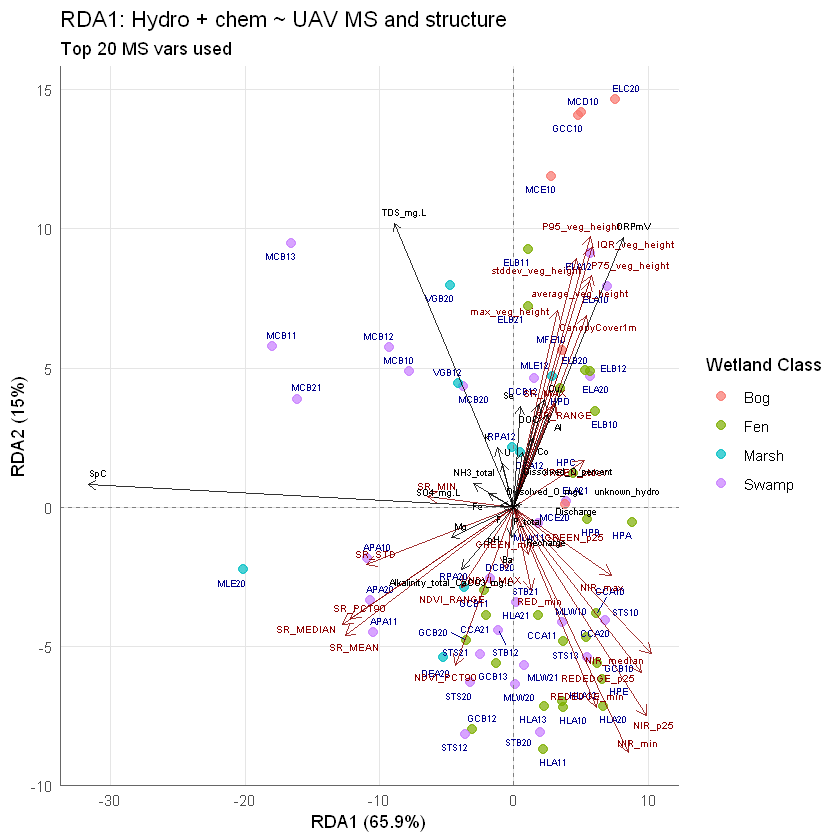

In [41]:
# ============================================================================
# STEP 10: Triplot
# ============================================================================

ggplot() +
  # Sites as points, colored by wetland class
  geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
             size = 2.5, alpha = 0.7) +
  
  # Site labels
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  
  # Vegetation predictor arrows (RED)
  geom_segment(data = arrow_scores,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "darkred", linewidth = 0.2, alpha = 0.8) +
  
  # Vegetation predictor labels
  geom_text_repel(data = arrow_scores,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "darkred", size = 2.2,
                  max.overlaps = 50,
                  segment.color = NA,
                  box.padding = 0.2) +
  
  # Hydrogeochemistry response arrows (BLACK)
  geom_segment(data = response_scores,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.2, "cm")), 
               color = "black", linewidth = 0.2, alpha = 0.8) +
  
  # Hydrogeochemistry response labels
  geom_text_repel(data = response_scores,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "black", size = 2,
                  max.overlaps = 200,
                  segment.color = NA) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title = "RDA1: Hydro + chem ~ UAV MS and structure",
    subtitle = "Top 20 MS vars used",
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right"
  )


Examine Loadings to reduce vars

In [38]:
predictor_loadings <- scores(rda1, display = "bp", scaling = 2)

loadings_df <- data.frame(
  Variable = rownames(predictor_loadings),
  RDA1 = predictor_loadings[, "RDA1"],
  RDA2 = predictor_loadings[, "RDA2"],
  RDA1_abs = abs(predictor_loadings[, "RDA1"]),
  RDA2_abs = abs(predictor_loadings[, "RDA2"])
)
cat("Top Loadings RDA 1 \n")
top_rda1 <- loadings_df %>%
  arrange(desc(RDA1_abs)) %>%
  select(Variable, RDA1, RDA1_abs) %>%
  slice(1:5)

print(top_rda1)
cat("Top Loadings RDA 2 \n")
top_rda2 <- loadings_df %>%
  arrange(desc(RDA2_abs)) %>%
  select(Variable, RDA2, RDA2_abs) %>%
  slice(1:5)

print(top_rda2)

# Get top 10 for each
top10_rda1 <- top_rda1 %>% slice(1:5)
top10_rda2 <- top_rda2 %>% slice(1:5)

# Create a nice comparison
cat("RDA1 AXIS (Main Gradient)              |  RDA2 AXIS (Secondary Gradient)\n")
cat("─────────────────────────────────────────────────────────────────────────────\n")

for (i in 1:5) {
  var1 <- if (i <= nrow(top10_rda1)) top10_rda1$Variable[i] else ""
  load1 <- if (i <= nrow(top10_rda1)) sprintf("%.4f", top10_rda1$RDA1_abs[i]) else ""
  
  var2 <- if (i <= nrow(top10_rda1)) top10_rda1$Variable[i] else ""
  load2 <- if (i <= nrow(top10_rda1)) sprintf("%.4f", top10_rda1$RDA2_abs[i]) else ""
  
  cat(sprintf("%-40s |  %-40s\n", 
              paste(var1, load1),
              paste(var2, load2)))
}

top_vars <- unique(c(top10_rda1$Variable, top10_rda2$Variable))

# Filter loadings to only these top variables
loadings_top <- loadings_df %>%
  filter(Variable %in% top_vars)


Top Loadings RDA 1 
             Variable       RDA1  RDA1_abs
SR_MEDIAN   SR_MEDIAN -0.6364194 0.6364194
SR_MEAN       SR_MEAN -0.6273200 0.6273200
SR_PCT90     SR_PCT90 -0.6070457 0.6070457
SR_STD         SR_STD -0.5468128 0.5468128
NIR_median NIR_median  0.5112616 0.5112616
Top Loadings RDA 2 
                           Variable       RDA2  RDA2_abs
P95_veg_height       P95_veg_height  0.4862152 0.4862152
IQR_veg_height       IQR_veg_height  0.4686861 0.4686861
stddev_veg_height stddev_veg_height  0.4460658 0.4460658
NIR_min                     NIR_min -0.4418197 0.4418197
P75_veg_height       P75_veg_height  0.4171533 0.4171533
RDA1 AXIS (Main Gradient)              |  RDA2 AXIS (Secondary Gradient)
-----------------------------------------------------------------------------
SR_MEDIAN 0.6364                         |  SR_MEDIAN                               
SR_MEAN 0.6273                           |  SR_MEAN                                 
SR_PCT90 0.6070                        

In [39]:
# ============================================================================
# EXTRACT RESPONSE LOADINGS
# ============================================================================

response_loadings <- scores(rda1, display = "species", scaling = 2)

response_df <- data.frame(
  Variable = rownames(response_loadings),
  RDA1 = response_loadings[, "RDA1"],
  RDA2 = response_loadings[, "RDA2"],
  RDA1_abs = abs(response_loadings[, "RDA1"]),
  RDA2_abs = abs(response_loadings[, "RDA2"])
)

# Get top 5 response variables for each axis
top5_resp_rda1 <- response_df %>%
  arrange(desc(RDA1_abs)) %>%
  slice(1:5)

top5_resp_rda2 <- response_df %>%
  arrange(desc(RDA2_abs)) %>%
  slice(1:5)

# Combine top response variables
top_resp_vars <- unique(c(top5_resp_rda1$Variable, top5_resp_rda2$Variable))
response_top <- response_df %>%
  filter(Variable %in% top_resp_vars)

cat("\nTop 5 Response Variables:\n")
print(response_top[, c("Variable", "RDA1", "RDA2")])


Top 5 Response Variables:
                                               Variable        RDA1      RDA2
Cu                                                   Cu   2.2585228  3.857477
TDS_mg.L                                       TDS_mg.L  -8.9003871 10.207349
DOC                                                 DOC   1.8335200  3.684534
Alkalinity_total_CaCO3_mg.L Alkalinity_total_CaCO3_mg.L  -3.8874140 -2.232468
Se                                                   Se   0.4629143  3.608765
Mg                                                   Mg  -4.6428294 -1.096134
SpC                                                 SpC -31.6583491  0.795877
ORPmV                                             ORPmV   8.1775585  9.688452


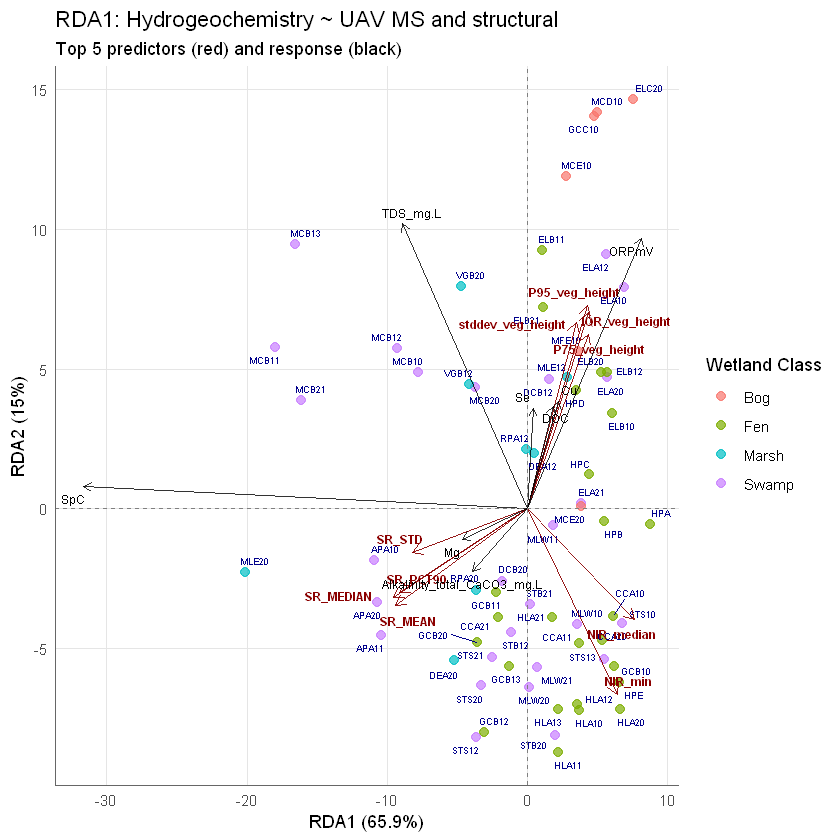

In [40]:
# ============================================================================
# EXTRACT SITE SCORES
# ============================================================================

site_scores <- as.data.frame(scores(rda1, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class

# Get axis labels
eig <- summary(rda1)$concont$importance[2, 1:2]
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

# ============================================================================
# Scale arrows for visibility
# ============================================================================

# Scale vegetation predictors (red arrows)
arrow_scale_pred <- 15
loadings_top$RDA1_scaled <- loadings_top$RDA1 * arrow_scale_pred
loadings_top$RDA2_scaled <- loadings_top$RDA2 * arrow_scale_pred

# Scale response variables (black arrows)
arrow_scale_resp <- 1
response_top$RDA1_scaled <- response_top$RDA1 * arrow_scale_resp
response_top$RDA2_scaled <- response_top$RDA2 * arrow_scale_resp

# ============================================================================
# Create Triplot with Top 10 Predictors
# ============================================================================

ggplot() +
  # Sites as points, colored by wetland class
  geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
             size = 2.5, alpha = 0.7) +
  
  # Site labels
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  
  # TOP PREDICTORS arrows (RED)
  geom_segment(data = loadings_top,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "darkred", linewidth = 0.5, alpha = 0.9) +
  
  # TOP PREDICTORS labels
  geom_text_repel(data = loadings_top,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "darkred", size = 2.5, fontface = "bold",
                  max.overlaps = 50,
                  segment.color = NA,
                  box.padding = 0.3) +
  
  # TOP RESPONSE arrows (black)
  geom_segment(data = response_top,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.2, "cm")), 
               color = "black", linewidth = 0.5, alpha = 0.8) +
  
  # TOP RESPONSE labels
  geom_text_repel(data = response_top,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "black", size = 2.5,
                  max.overlaps = 100,
                  segment.color = NA,
                  box.padding = 0.2) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title = "RDA1: Hydrogeochemistry ~ UAV MS and structural",
    subtitle = "Top 5 predictors (red) and response (black)",
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right"
  )


#### RDA1.0 RDA3 VS RDA2


========== TOP PREDICTOR VARIABLES (RDA1 & RDA3) ==========
                 Variable        RDA1        RDA3
NDVI_MAX         NDVI_MAX -0.04458325  0.16342344
NDVI_RANGE     NDVI_RANGE -0.17474446 -0.17616448
NDVI_PCT90     NDVI_PCT90 -0.22854303  0.15862239
NDGVI_MAX       NDGVI_MAX  0.26946746 -0.13442825
SR_MIN             SR_MIN -0.33772595  0.14706024
SR_MEAN           SR_MEAN -0.63489570  0.05329095
SR_STD             SR_STD -0.55527242  0.02617335
SR_MEDIAN       SR_MEDIAN -0.64187045  0.04771927
SR_PCT90         SR_PCT90 -0.61800161  0.07710349
GREEN_median GREEN_median  0.21330898  0.11260466
GREEN_p25       GREEN_p25  0.16601944  0.09440042
GREEN_p75       GREEN_p75  0.20823623  0.10878270
GREEN_p95       GREEN_p95  0.19711424  0.08757410
GREEN_stdev   GREEN_stdev  0.25323248  0.09136388

========== RESPONSE LOADINGS (RDA1 & RDA3) ==========
                                               Variable          RDA1
Al                                                   Al  2.64732

Warning message:
"ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


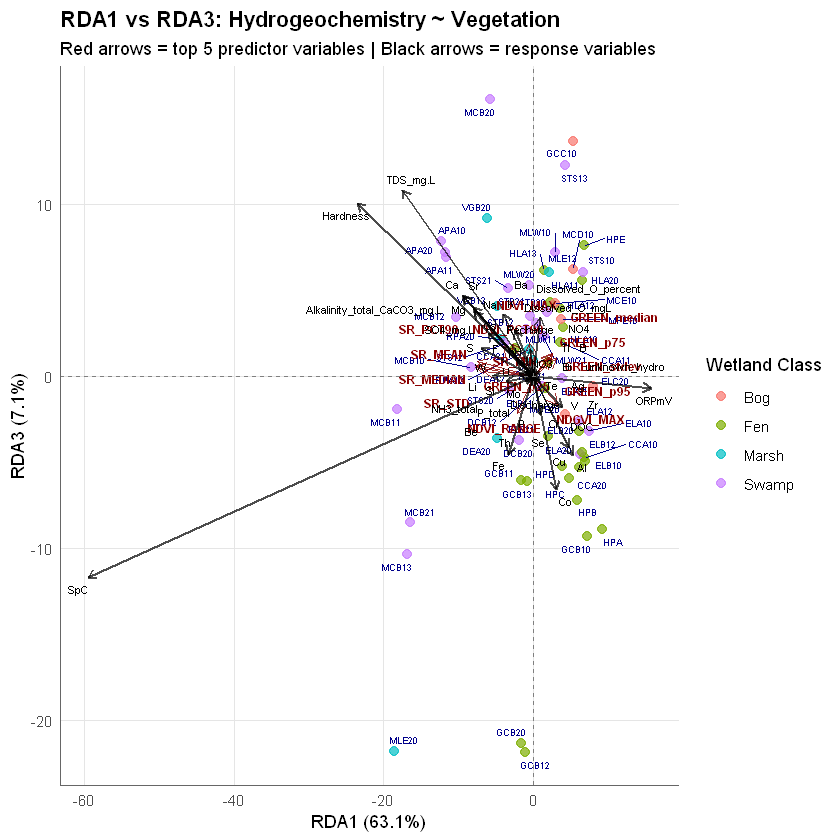

In [100]:
# ============================================================================
# RDA1 vs RDA3 Triplot: Full Variable Set
# ============================================================================
# ============================================================================
# EXTRACT SITE SCORES (RDA1 & RDA3)
# ============================================================================

# Must specify choices = c(1, 3) to get RDA1 and RDA3
site_scores <- as.data.frame(scores(rda1, display = "sites", scaling = 2, choices = c(1, 3)))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class[match(site_scores$SiteID, df$SiteID)]

# Rename columns (choices = c(1,3) creates PC1 and PC2, so rename to RDA1 and RDA3)
colnames(site_scores)[1:2] <- c("RDA1", "RDA3")

# ============================================================================
# EXTRACT PREDICTOR LOADINGS (RDA1 & RDA3)
# ============================================================================

predictor_loadings <- scores(rda1, display = "bp", scaling = 2, choices = c(1, 3))

loadings_df <- data.frame(
  Variable = rownames(predictor_loadings),
  RDA1 = predictor_loadings[, 1],
  RDA3 = predictor_loadings[, 2],
  RDA1_abs = abs(predictor_loadings[, 1]),
  RDA3_abs = abs(predictor_loadings[, 2])
)

# Get top predictors by each axis
top_pred_rda1 <- loadings_df %>%
  arrange(desc(RDA1_abs)) %>%
  slice(1:5) %>%
  pull(Variable)

top_pred_rda3 <- loadings_df %>%
  arrange(desc(RDA3_abs)) %>%
  slice(1:10) %>%
  pull(Variable)

# Combine to get unique top predictors
top_pred_vars <- unique(c(top_pred_rda1, top_pred_rda3))

# Filter to only top predictors
loadings_df <- loadings_df %>%
  filter(Variable %in% top_pred_vars) %>%
  select(Variable, RDA1, RDA3)

cat("\n========== TOP PREDICTOR VARIABLES (RDA1 & RDA3) ==========\n")
print(loadings_df)

# ============================================================================
# EXTRACT RESPONSE LOADINGS (RDA1 & RDA3)
# ============================================================================

response_loadings <- scores(rda1, display = "species", scaling = 2, choices = c(1, 3))

response_df <- data.frame(
  Variable = rownames(response_loadings),
  RDA1 = response_loadings[, 1],
  RDA3 = response_loadings[, 2]
)

cat("\n========== RESPONSE LOADINGS (RDA1 & RDA3) ==========\n")
print(response_df)

# ============================================================================
# GET AXIS LABELS WITH VARIANCE EXPLAINED
# ============================================================================

rda_summary <- summary(rda1)
eig <- rda_summary$concont$importance[2, c("RDA1", "RDA3")]

xlab_pct <- paste0("RDA1 (", round(eig["RDA1"] * 100, 1), "%)")
ylab_pct <- paste0("RDA3 (", round(eig["RDA3"] * 100, 1), "%)")

# ============================================================================
# SCALE ARROWS FOR VISIBILITY
# ============================================================================

# Scale predictors (red arrows) — adjust multiplier as needed
arrow_scale_pred <- 12
loadings_df$RDA1_scaled <- loadings_df$RDA1 * arrow_scale_pred
loadings_df$RDA3_scaled <- loadings_df$RDA3 * arrow_scale_pred

# Scale response (black arrows) — usually smaller
arrow_scale_resp <- 2
response_df$RDA1_scaled <- response_df$RDA1 * arrow_scale_resp
response_df$RDA3_scaled <- response_df$RDA3 * arrow_scale_resp

# ============================================================================
# CREATE TRIPLOT
# ============================================================================

ggplot() +
  
  # SITE POINTS
  geom_point(data = site_scores, 
             aes(x = RDA1, y = RDA3, color = Class), 
             size = 2.5, alpha = 0.7) +
  
  # SITE LABELS
  geom_text_repel(data = site_scores, 
                  aes(x = RDA1, y = RDA3, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 15) +
  
  # PREDICTOR ARROWS (RED)
  geom_segment(data = loadings_df,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA3_scaled),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "darkred", linewidth = 0.5, alpha = 0.8) +
  
  # PREDICTOR LABELS
  geom_text_repel(data = loadings_df,
                  aes(x = RDA1_scaled, y = RDA3_scaled, label = Variable),
                  color = "darkred", size = 2.5, fontface = "bold",
                  max.overlaps = 50,
                  segment.color = NA,
                  box.padding = 0.3) +
  
  # RESPONSE ARROWS (BLACK)
  geom_segment(data = response_df,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA3_scaled),
               arrow = arrow(length = unit(0.2, "cm")), 
               color = "black", linewidth = 0.6, alpha = 0.7) +
  
  # RESPONSE LABELS
  geom_text_repel(data = response_df,
                  aes(x = RDA1_scaled, y = RDA3_scaled, label = Variable),
                  color = "black", size = 2.3,
                  max.overlaps = 100,
                  segment.color = NA,
                  box.padding = 0.2) +
  
  # REFERENCE LINES
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  # LABELS & THEME
  labs(
    title = "RDA1 vs RDA3: Hydrogeochemistry ~ Vegetation",
    subtitle = "Red arrows = top 5 predictor variables | Black arrows = response variables",
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right",
    plot.title = element_text(size = 13, face = "bold"),
    plot.subtitle = element_text(size = 11)
  )



### RDA1.1 and 1.2 (MS only and structure only)

In [129]:
# ============================================================================
# RDA1.1 Only Multispectral Indices (MS)
# ============================================================================

cat("\n========== RDA1 WITH ONLY MULTISPECTRAL INDICES ==========\n")

predictors_ms <- df[, ms_cols]
rownames(predictors_ms) <- df$SiteID

rda1_ms <- rda(response ~ ., data = predictors_ms)

cat("Summary:\n")
print(RsquareAdj(rda1_ms))

cat("\nANOVA:\n")
print(anova(rda1_ms))

# ============================================================================
# RDA_model1.2 Only Structural Variables
# ============================================================================

cat("\n========== RDA1 WITH ONLY STRUCTURAL VARIABLES ==========\n")

predictors_struct <- df[, struct_cols]
rownames(predictors_struct) <- df$SiteID

rda1_struct <- rda(response ~ ., data = predictors_struct)

cat("Summary:\n")
print(RsquareAdj(rda1_struct))

cat("\nANOVA:\n")
print(anova(rda1_struct))

# ============================================================================
# RDA1.0 Both (Current Full Model)
# ============================================================================

cat("\n========== RDA1 WITH BOTH MS + STRUCTURE ==========\n")

predictors_both <- df[, c(ms_cols, struct_cols)]
rownames(predictors_both) <- df$SiteID

rda1_both <- rda(response ~ ., data = predictors_both)

cat("Summary:\n")
print(RsquareAdj(rda1_both))

cat("\nANOVA:\n")
print(anova(rda1_both))

# ============================================================================
# COMPARISON
# ============================================================================

cat("\n========== COMPARISON ==========\n\n")

comparison <- data.frame(
  Model = c("Multispectral Only", "Structure Only", "Both MS + Structure"),
  Adj_R2 = c(
    RsquareAdj(rda1_ms)$adj.r.squared,
    RsquareAdj(rda1_struct)$adj.r.squared,
    RsquareAdj(rda1_both)$adj.r.squared
  ),
  Num_Predictors = c(
    ncol(predictors_ms),
    ncol(predictors_struct),
    ncol(predictors_both)
  )
)

print(comparison)

# ============================================================================
# Then use whichever model you prefer!
# ============================================================================

cat("\n\nTo use one of these models for your plots:\n")
cat("rda1 <- rda1_ms        # for spectral only\n")
cat("rda1 <- rda1_struct    # for structure only\n")
cat("rda1 <- rda1_both      # for both (current)\n")


========== RDA1 WITH ONLY MULTISPECTRAL INDICES ==========
Summary:
$r.squared
[1] 0.4985925

$adj.r.squared
[1] 0.4074275


ANOVA:
Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = response ~ REDEDGE_min + SR_STD + RED_min + SR_RANGE + NIR_min + SR_MAX + SR_PCT90 + SR_MEAN + REDEDGE_p25 + NIR_median, data = predictors_ms)
         Df Variance      F Pr(>F)    
Model    10    40968 5.4691  0.001 ***
Residual 55    41199                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

========== RDA1 WITH ONLY STRUCTURAL VARIABLES ==========
Summary:
$r.squared
[1] 0.1940347

$adj.r.squared
[1] 0.08091681


ANOVA:
Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = response ~ average_veg_height + stddev_veg_height + P75_veg_height + P95_veg_height + IQR_veg_height + CanopyCover1m + max_veg_height + stem_density, data = predictors_struct)
     

In [77]:
library(patchwork)  # for combining plots

# ============================================================================
# Fit the three models
# ============================================================================

# Model 1: Multispectral only
predictors_ms <- df[, ms_cols]
rownames(predictors_ms) <- df$SiteID
rda1_ms <- rda(response ~ ., data = predictors_ms)

# Model 2: Structure only
predictors_struct <- df[, struct_cols]
rownames(predictors_struct) <- df$SiteID
rda1_struct <- rda(response ~ ., data = predictors_struct)

# Model 3: Both
predictors_both <- df[, c(ms_cols, struct_cols)]
rownames(predictors_both) <- df$SiteID
rda1_both <- rda(response ~ ., data = predictors_both)

# ============================================================================
# Function to create triplot for any RDA model
# ============================================================================

create_rda_triplot <- function(rda_model, model_name, df_input) {
  
  # Extract site scores
  site_scores <- as.data.frame(scores(rda_model, display = "sites", scaling = 2))
  site_scores$SiteID <- rownames(site_scores)
  site_scores$Class <- df_input$Class
  
  # Extract predictor loadings
  predictor_loadings <- scores(rda_model, display = "bp", scaling = 2)
  loadings_df <- data.frame(
    Variable = rownames(predictor_loadings),
    RDA1 = predictor_loadings[, "RDA1"],
    RDA2 = predictor_loadings[, "RDA2"]
  )
  
  # Extract response loadings
  response_loadings <- scores(rda_model, display = "species", scaling = 2)
  response_df <- data.frame(
    Variable = rownames(response_loadings),
    RDA1 = response_loadings[, "RDA1"],
    RDA2 = response_loadings[, "RDA2"]
  )
  
  # Get axis labels
  eig <- summary(rda_model)$concont$importance[2, 1:2]
  xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
  ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")
  
  # Scale arrows
  arrow_scale_pred <- 15
  loadings_df$RDA1_scaled <- loadings_df$RDA1 * arrow_scale_pred
  loadings_df$RDA2_scaled <- loadings_df$RDA2 * arrow_scale_pred
  
  arrow_scale_resp <- 0.8
  response_df$RDA1_scaled <- response_df$RDA1 * arrow_scale_resp
  response_df$RDA2_scaled <- response_df$RDA2 * arrow_scale_resp
  
  # Create plot
  plot <- ggplot() +
    # Sites
    geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
               size = 2.5, alpha = 0.7) +
    
    # Site labels
    geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                    color = "darkblue", size = 1.5, max.overlaps = 5) +
    
    # Predictor arrows (RED)
    geom_segment(data = loadings_df,
                 aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
                 arrow = arrow(length = unit(0.2, "cm")), 
                 color = "darkred", linewidth = 0.5, alpha = 0.7) +
    
    # Predictor labels
    geom_text_repel(data = loadings_df,
                    aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                    color = "darkred", size = 2, fontface = "bold",
                    max.overlaps = 30,
                    segment.color = NA,
                    box.padding = 0.2) +
    
    # Response arrows (GREEN)
    geom_segment(data = response_df,
                 aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
                 arrow = arrow(length = unit(0.15, "cm")), 
                 color = "black", linewidth = 0.5, alpha = 0.7) +
    
    # Response labels
    geom_text_repel(data = response_df,
                    aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                    color = "black", size = 1.5,
                    max.overlaps = 100,
                    segment.color = NA,
                    box.padding = 0.15) +
    
    # Reference lines
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
    
    labs(
      title = model_name,
      x = xlab_pct,
      y = ylab_pct,
      color = "Class"
    ) +
    theme_minimal(base_size = 9) +
    theme(
      panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
      panel.grid.minor = element_blank(),
      axis.line = element_line(color = "grey40", linewidth = 0.3),
      legend.position = "right",
      plot.title = element_text(face = "bold", size = 10)
    )
  
  return(plot)
}

# ============================================================================
# Create the three plots
# ============================================================================

plot1 <- create_rda_triplot(rda1_ms, 
                            paste0("Multispectral Only\n(Adj R² = ", 
                                   round(RsquareAdj(rda1_ms)$adj.r.squared, 3), ")"),
                            df)

plot2 <- create_rda_triplot(rda1_struct, 
                            paste0("Structure Only\n(Adj R² = ", 
                                   round(RsquareAdj(rda1_struct)$adj.r.squared, 3), ")"),
                            df)

plot3 <- create_rda_triplot(rda1_both, 
                            paste0("Spectral + Structure\n(Adj R² = ", 
                                   round(RsquareAdj(rda1_both)$adj.r.squared, 3), ")"),
                            df)

Warning message:
"ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


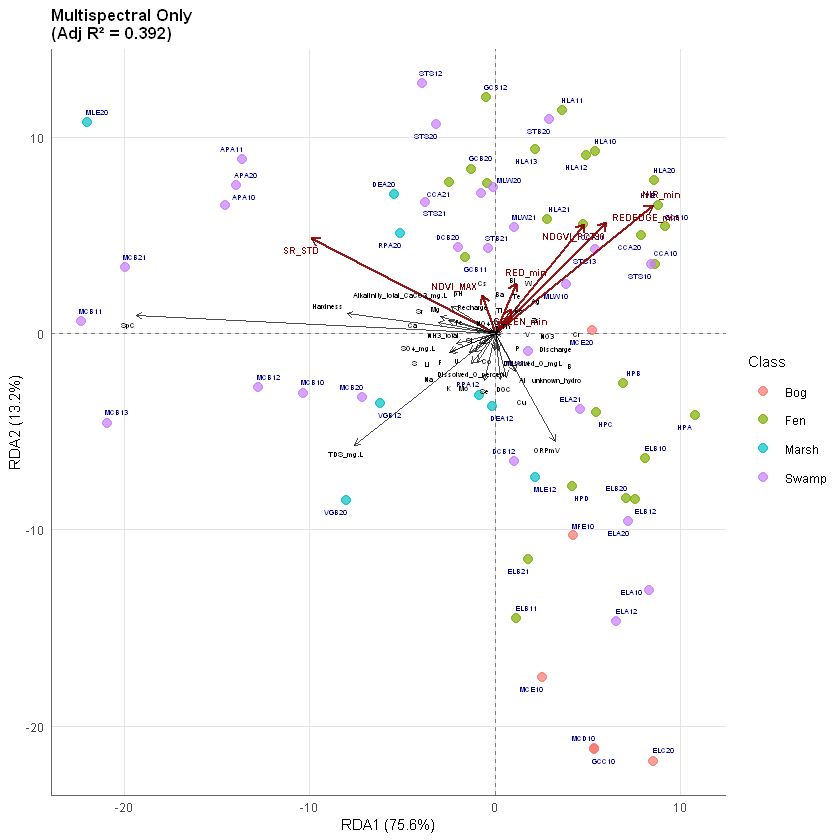

In [76]:
plot1

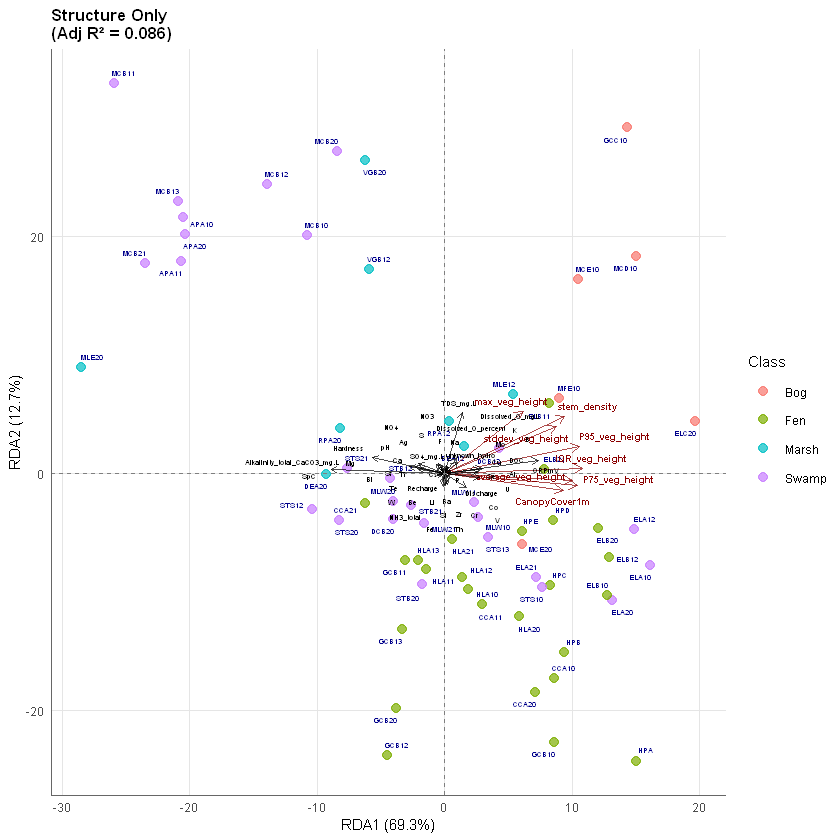

In [78]:
plot2

### Old work


========== PERMANOVA: DO WETLAND CLASSES DIFFER SIGNIFICANTLY? ==========



Warning message in vegdist(as.matrix(lhs), method = method, ...):
"results may be meaningless because data have negative entries
                 in method "bray""


PERMANOVA Results:
Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = site_scores_rda ~ site_class, permutations = 999)
           Df SumOfSqs      R2      F Pr(>F)  
site_class  3    73107 0.98215 1137.4   0.03 *
Residual   62     1328 0.01785                
Total      65    74436 1.00000                
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Interpretation:
R² = 0.9822 (Wetland class explains 98.22% of ordination variation)
p-value = 0.0300 *** SIGNIFICANT - Classes differ significantly! ***

========== BETA-DISPERSION: HOW TIGHTLY CLUSTERED ARE CLASSES? ==========

Beta-dispersion Results:

	Homogeneity of multivariate dispersions

Call: betadisper(d = dist(site_scores_rda), group = site_class)

No. of Positive Eigenvalues: 2
No. of Negative Eigenvalues: 0

Average distance to median:
  Bog   Fen Marsh Swamp 
5.463 4.861 6.714 7.964 

Eigenvalues for P

Warning message:
"ggrepel: 17 unlabeled data points (too many overlaps). Consider increasing max.overlaps"



========== PAIRWISE COMPARISONS: WHICH CLASSES DIFFER? ==========

Testing all pairs of wetland classes:



...

Fen vs Marsh:  R² = 0.648, p = 0.3510 


Warning message in vegdist(as.matrix(lhs), method = method, ...):
"results may be meaningless because data have negative entries
                 in method "bray""


Fen vs Bog:  R² = 0.997, p = 0.0020 ***


Warning message in vegdist(as.matrix(lhs), method = method, ...):
"results may be meaningless because data have negative entries
                 in method "bray""


Marsh vs Bog:  R² = 0.117, p = 0.4940 

========== CONCLUSIONS ==========
If PERMANOVA p < 0.05: Classes are significantly different
If convex hulls overlap: Some classes have similar conditions
If convex hulls separate: Classes occupy distinct ecological space


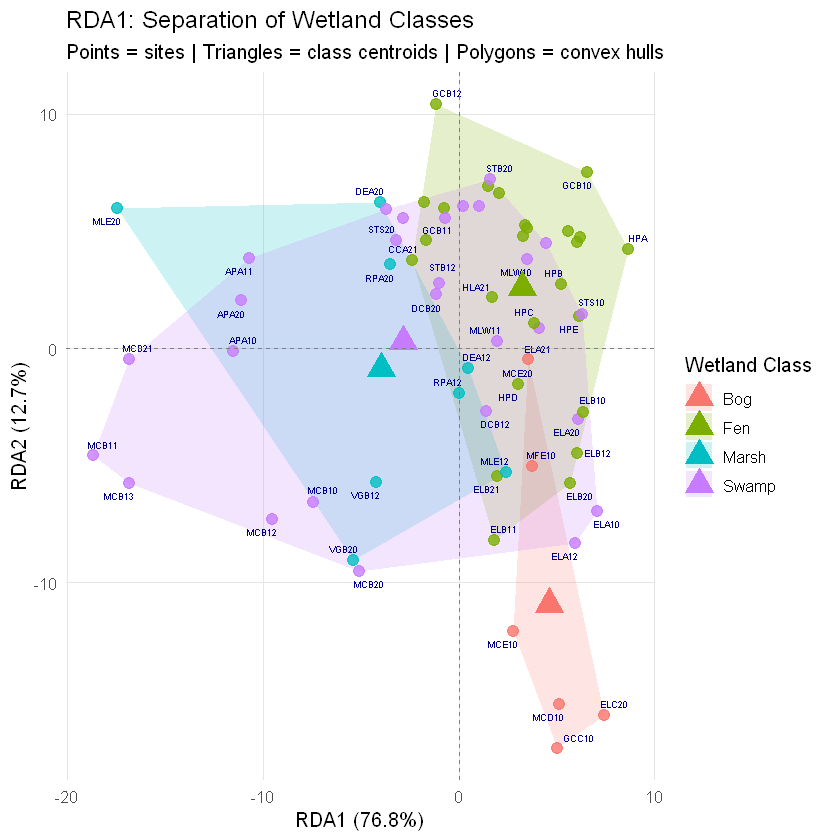

In [81]:
# ============================================================================
# STEP 1: PERMANOVA - Test if classes differ significantly
# ============================================================================

cat("\n========== PERMANOVA: DO WETLAND CLASSES DIFFER SIGNIFICANTLY? ==========\n\n")

# Get site scores from RDA1
site_scores_rda <- scores(rda1, display = "sites", scaling = 2)
site_class <- df$Class

# Run PERMANOVA (adonis2 function from vegan)
permanova_result <- adonis2(site_scores_rda ~ site_class, permutations = 999)

cat("PERMANOVA Results:\n")
print(permanova_result)

# Extract results
p_value <- permanova_result$`Pr(>F)`[1]
r_squared <- permanova_result$R2[1]

cat(sprintf("\nInterpretation:\n"))
cat(sprintf("R² = %.4f (Wetland class explains %.2f%% of ordination variation)\n", 
            r_squared, r_squared * 100))
cat(sprintf("p-value = %.4f ", p_value))
if (p_value < 0.05) {
  cat("*** SIGNIFICANT - Classes differ significantly! ***\n")
} else {
  cat("(Not significant)\n")
}

# ============================================================================
# STEP 2: Multivariate Dispersion - Are classes tightly clustered?
# ============================================================================

cat("\n========== BETA-DISPERSION: HOW TIGHTLY CLUSTERED ARE CLASSES? ==========\n\n")

# Calculate beta-dispersion (multivariate spread within groups)
betadisp_result <- betadisper(dist(site_scores_rda), site_class)

cat("Beta-dispersion Results:\n")
print(betadisp_result)

# Test if groups have different dispersion
dispersion_test <- permutest(betadisp_result, permutations = 999)

cat("\nDispersion test p-value:", dispersion_test$tab$`Pr(>F)`[1], "\n")
if (dispersion_test$tab$`Pr(>F)`[1] < 0.05) {
  cat("Classes have DIFFERENT dispersions (some are more tightly clustered)\n")
} else {
  cat("Classes have SIMILAR dispersions\n")
}

# ============================================================================
# STEP 3: Summary Statistics by Class
# ============================================================================

cat("\n========== SUMMARY STATISTICS BY WETLAND CLASS ==========\n\n")

site_summary <- data.frame(
  RDA1 = site_scores_rda[, "RDA1"],
  RDA2 = site_scores_rda[, "RDA2"],
  Class = site_class
)

class_summary <- site_summary %>%
  group_by(Class) %>%
  summarise(
    N = n(),
    RDA1_mean = mean(RDA1),
    RDA1_sd = sd(RDA1),
    RDA2_mean = mean(RDA2),
    RDA2_sd = sd(RDA2),
    .groups = "drop"
  )

print(class_summary)

cat("\nInterpretation:\n")
cat("- Classes with different RDA1/RDA2 means are separated along those axes\n")
cat("- Larger SD indicates more spread (less tight clustering)\n")

# ============================================================================
# STEP 4: Visualize Separation with Convex Hulls
# ============================================================================

cat("\n========== CREATING VISUALIZATION WITH CONVEX HULLS ==========\n\n")

# Get site scores
site_scores <- as.data.frame(scores(rda1, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class

# Calculate convex hull for each class
hulls <- site_scores %>%
  group_by(Class) %>%
  slice(chull(RDA1, RDA2)) %>%
  ungroup()

# Create the plot
ggplot() +
  # Convex hulls for each class (filled)
  geom_polygon(data = hulls,
               aes(x = RDA1, y = RDA2, fill = Class),
               alpha = 0.2) +
  
  # Site points
  geom_point(data = site_scores,
             aes(x = RDA1, y = RDA2, color = Class),
             size = 3, alpha = 0.8) +
  
  # Site labels (optional - comment out if too crowded)
  geom_text_repel(data = site_scores,
                  aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 5) +
  
  # Centroid for each class
  geom_point(data = class_summary,
             aes(x = RDA1_mean, y = RDA2_mean, color = Class),
             size = 5, shape = 17, stroke = 2) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  
  labs(
    title = "RDA1: Separation of Wetland Classes",
    subtitle = "Points = sites | Triangles = class centroids | Polygons = convex hulls",
    x = paste0("RDA1 (", round(summary(rda1)$concont$importance[2, 1] * 100, 1), "%)"),
    y = paste0("RDA2 (", round(summary(rda1)$concont$importance[2, 2] * 100, 1), "%)"),
    color = "Wetland Class",
    fill = "Wetland Class"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

# ============================================================================
# STEP 5: Pairwise Comparisons (Which classes differ from which?)
# ============================================================================

cat("\n========== PAIRWISE COMPARISONS: WHICH CLASSES DIFFER? ==========\n\n")

# Get unique class pairs
classes <- unique(site_class)
n_classes <- length(classes)

cat("Testing all pairs of wetland classes:\n\n")

for (i in 1:(n_classes-1)) {
  for (j in (i+1):n_classes) {
    class1 <- classes[i]
    class2 <- classes[j]
    
    # Subset data for these two classes
    subset_sites <- site_scores_rda[site_class %in% c(class1, class2), ]
    subset_class <- site_class[site_class %in% c(class1, class2)]
    
    # Run PERMANOVA for this pair
    result <- adonis2(subset_sites ~ subset_class, permutations = 999)
    p_val <- result$`Pr(>F)`[1]
    r2 <- result$R2[1]
    
    sig <- if (p_val < 0.05) "***" else ""
    cat(sprintf("%s vs %s:  R² = %.3f, p = %.4f %s\n", 
                class1, class2, r2, p_val, sig))
  }
}

cat("\n========== CONCLUSIONS ==========\n")
cat("If PERMANOVA p < 0.05: Classes are significantly different\n")
cat("If convex hulls overlap: Some classes have similar conditions\n")
cat("If convex hulls separate: Classes occupy distinct ecological space\n")



In [19]:
vif_results <- vif.cca(rda1)

# Create a dataframe for easier viewing and sorting
vif_df <- data.frame(
  Variable = names(vif_results),
  VIF = as.numeric(vif_results),
  row.names = NULL
)

# Sort by VIF (highest first)
vif_df <- vif_df[order(vif_df$VIF, decreasing = TRUE), ]
print(vif_df)

             Variable          VIF
11             SR_MAX 1.896971e+18
12           SR_RANGE 1.896953e+18
10             SR_MIN 2.282624e+15
19     P75_veg_height 1.992726e+14
16  median_veg_height 1.387414e+14
20     IQR_veg_height 7.636138e+13
15 average_veg_height 5.859951e+13
6          NDGVI_MEAN 5.760765e+13
9         NDGVI_PCT90 1.647191e+13
18     P95_veg_height 8.008910e+12
8        NDGVI_MEDIAN 7.915679e+12
7           NDGVI_STD 2.509462e+12
21      CanopyCover1m 8.869940e+11
14             SR_STD 3.739254e+11
1            NDVI_MIN 7.069313e+10
17     max_veg_height 6.740227e+10
3            NDVI_STD 4.787646e+10
4          NDVI_PCT90 4.768795e+10
5           NDGVI_MIN 4.624572e+10
2            NDVI_MAX 9.991728e+09
13            SR_MEAN 2.250079e+09
22       stem_density           NA


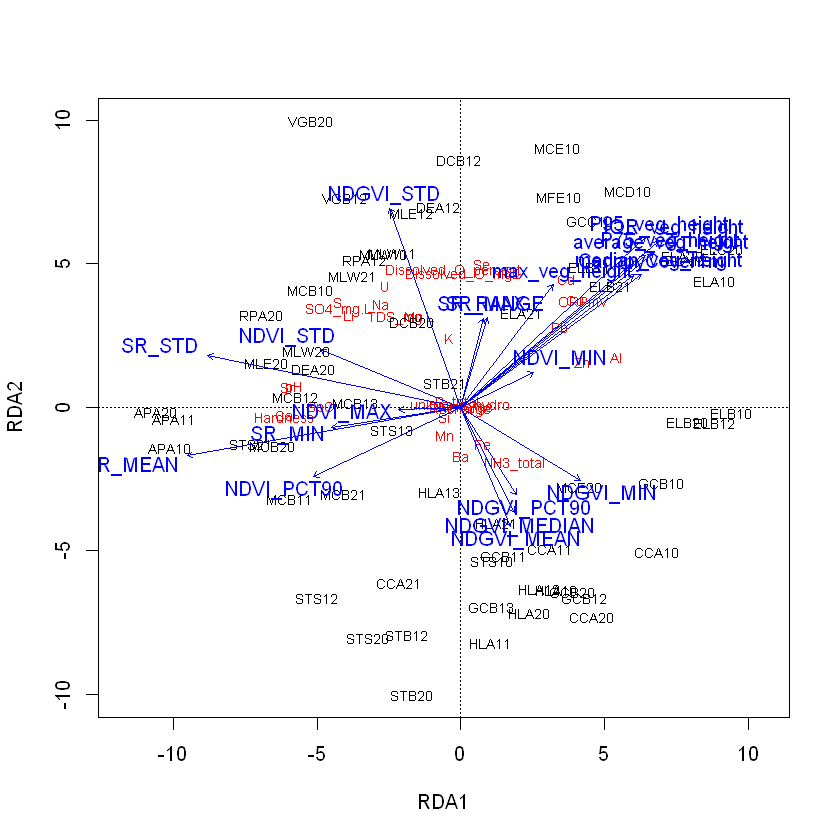

In [20]:
# Basic biplot
# Basic biplot with both sites and species/predictors
plot(rda1, scaling = 2)

In [21]:
RsquareAdj(rda1)

$r.squared
[1] 0.6938054

$adj.r.squared
[1] 0.5289313

In [22]:
# Overall model significance
anova.cca(rda1, permutations = 999)

# Test each axis
anova.cca(rda1, by = "axis", permutations = 999)

# Indiviual predictor significance
anova(rda1, by = "terms")



,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,21,24960.06,4.208093,0.001
Residual,39,11015.54,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,8757.774424,31.00650123,0.001
RDA2,1,6268.539872,22.19347974,0.001
RDA3,1,3554.813715,12.58565596,0.005
RDA4,1,1532.905288,5.42718132,0.483
RDA5,1,1134.088871,4.01518996,0.825
RDA6,1,1043.993297,3.69621069,0.884
RDA7,1,701.940758,2.48518926,0.994
RDA8,1,413.050321,1.46238584,1.000
RDA9,1,362.724558,1.28420977,1.000


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
NDVI_MIN,1,602.8330,2.1343026,0.047
NDVI_MAX,1,686.6446,2.4310339,0.029
NDVI_STD,1,2103.0884,7.4458886,0.001
NDVI_PCT90,1,3072.3090,10.8773701,0.001
NDGVI_MIN,1,1933.7273,6.8462735,0.001
NDGVI_MEAN,1,711.5880,2.5193450,0.017
NDGVI_STD,1,2330.0944,8.2495931,0.001
NDGVI_MEDIAN,1,2410.6968,8.5349620,0.001
NDGVI_PCT90,1,1173.5268,4.1548183,0.004


                          RDA1        RDA2            Variable distance
Ca                  -6.1528595 -0.27526444                  Ca 6.159014
Hardness            -6.1478259 -0.34695340            Hardness 6.157608
Sr                  -6.0534822  0.72783671                  Sr 6.097081
pH                  -5.7958119  0.68556577                  pH 5.836218
Cd                   3.6832447  4.46145704                  Cd 5.785403
Al                   5.4058053  1.75521649                  Al 5.683618
ORPmV                4.2607383  3.70532466               ORPmV 5.646532
S                   -4.2785597  3.67059345                   S 5.637316
Cu                   3.9768697  3.75106754                  Cu 5.466809
SO4_mg.L            -4.2188375  3.40526419            SO4_mg.L 5.421662
Sb                   1.8019277  4.76894013                  Sb 5.098013
Li                  -3.8684567  3.22614301                  Li 5.037158
Se                   0.7444392  4.98031290                  Se 5

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
i Please use the `linewidth` argument instead."


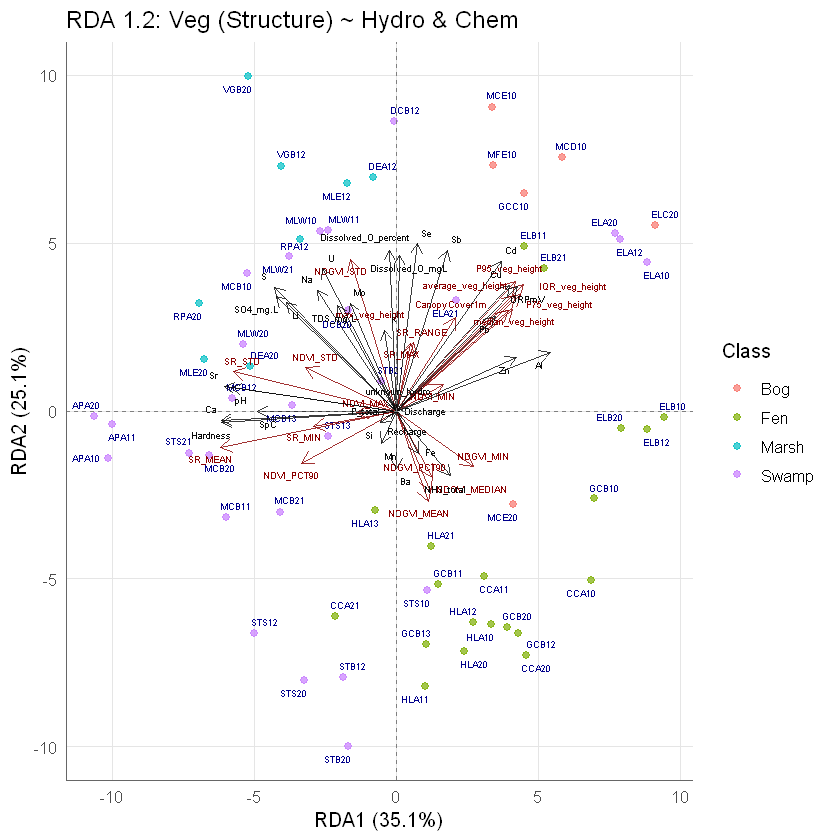

: 

In [ ]:
# Now run the ggplot code from before
site_scores <- as.data.frame(scores(rda1, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class  

arrow_scores <- as.data.frame(scores(rda1, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

response_scores <- as.data.frame(scores(rda1, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# Get axis labels
eig <- summary(rda1)$concont$importance[2, 1:2]
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

# Scale arrows
arrow_scale <- 10
arrow_scores$RDA1 <- arrow_scores$RDA1 * arrow_scale
arrow_scores$RDA2 <- arrow_scores$RDA2 * arrow_scale

response_scores$RDA1 <- response_scores$RDA1 * 10
response_scores$RDA2 <- response_scores$RDA2 * 10

# --- response (species) scores, unscaled for plotting ---
response_scores <- as.data.frame(scores(rda1, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# Rank by vector length on RDA1–RDA2
response_ranked <- response_scores %>%
  mutate(distance = sqrt(RDA1^2 + RDA2^2)) %>%
  arrange(desc(distance))

# Print the top N so you can see them
N_top <- 20
print(response_ranked[1:N_top, ])


# Create ggplot
ggplot() +
  geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
                 , size = 2, alpha = 0.7) +
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  geom_segment(data = arrow_scores,
               aes(x = 0, y = 0, xend = RDA1, yend = RDA2),
               arrow = arrow(length = unit(0.3, "cm")), 
               color = "darkred", linewidth = 0.1, alpha = 0.8) +
  geom_text_repel(data = arrow_scores,
                  aes(x = RDA1, y = RDA2, label = Variable),
                  color = "darkred", size = 2,
                  max.overlaps = 50, segment.color = NA, box.padding = 0.2) +
  geom_segment(data = response_scores,
               aes(x = 0, y = 0, xend = RDA1, yend = RDA2),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "grey4", linewidth = 0.5, alpha = 0.8) +
  geom_text_repel(data = response_scores,
                  aes(x = RDA1, y = RDA2, label = Variable),
                  color = "grey4", size = 2,
                  max.overlaps = 100, segment.color = NA) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", size = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", size = 0.3) +
  labs(title = "RDA 1.2: Veg (Structure) ~ Hydro & Chem",
       x = xlab_pct, y = ylab_pct) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.major = element_line(color = "grey90", size = 0.2),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "grey40", size = 0.3))

#ggsave("rda1_biplot.pdf", width = 14, height = 10)

In [ ]:
vif_values <- vif.cca(rda1)
print(vif_values)

# Remove redundant columns: Hardness and Dissolved_O_percent
predictors_reduced <- predictors[, !colnames(predictors) %in% c("Hardness", "Dissolved_O_percent", "S")]

# Fit RDA with reduced predictors
rda1_reduced <- rda(response ~ ., data = predictors_reduced)
summary(rda1_reduced)

# Calculate VIF for reduced model
vif_reduced <- vif.cca(rda1_reduced)
print(vif_reduced)

# Overall model significance
anova.cca(rda1_reduced, permutations = 999)

# Test each axis
anova.cca(rda1_reduced, by = "axis", permutations = 999)

RsquareAdj(rda1_reduced)

          NDVI_MIN           NDVI_MAX           NDVI_STD         NDVI_PCT90 
      7.069313e+10       9.991728e+09       4.787646e+10       4.768795e+10 
         NDGVI_MIN         NDGVI_MEAN          NDGVI_STD       NDGVI_MEDIAN 
      4.624572e+10       5.760765e+13       2.509462e+12       7.915679e+12 
       NDGVI_PCT90             SR_MIN             SR_MAX           SR_RANGE 
      1.647191e+13       2.282624e+15       1.896971e+18       1.896953e+18 
           SR_MEAN             SR_STD average_veg_height  median_veg_height 
      2.250079e+09       3.739254e+11       5.859951e+13       1.387414e+14 
    max_veg_height     P95_veg_height     P75_veg_height     IQR_veg_height 
      6.740227e+10       8.008910e+12       1.992726e+14       7.636138e+13 
     CanopyCover1m       stem_density 
      8.869940e+11                 NA 



Call:
rda(formula = response ~ NDVI_MIN + NDVI_MAX + NDVI_STD + NDVI_PCT90 +      NDGVI_MIN + NDGVI_MEAN + NDGVI_STD + NDGVI_MEDIAN + NDGVI_PCT90 +      SR_MIN + SR_MAX + SR_RANGE + SR_MEAN + SR_STD + average_veg_height +      median_veg_height + max_veg_height + P95_veg_height + P75_veg_height +      IQR_veg_height + CanopyCover1m + stem_density, data = predictors_reduced) 

Partitioning of variance:
              Inertia Proportion
Total           35976     1.0000
Constrained     24960     0.6938
Unconstrained   11016     0.3062

Eigenvalues, and their contribution to the variance 

Importance of components:
                           RDA1      RDA2      RDA3      RDA4      RDA5
Eigenvalue            8757.7744 6268.5399 3.555e+03 1.533e+03 1.134e+03
Proportion Explained     0.2434    0.1742 9.881e-02 4.261e-02 3.152e-02
Cumulative Proportion    0.2434    0.4177 5.165e-01 5.591e-01 5.906e-01
                           RDA6      RDA7      RDA8      RDA9     RDA10
Eigenvalue           

          NDVI_MIN           NDVI_MAX           NDVI_STD         NDVI_PCT90 
      7.069313e+10       9.991728e+09       4.787646e+10       4.768795e+10 
         NDGVI_MIN         NDGVI_MEAN          NDGVI_STD       NDGVI_MEDIAN 
      4.624572e+10       5.760765e+13       2.509462e+12       7.915679e+12 
       NDGVI_PCT90             SR_MIN             SR_MAX           SR_RANGE 
      1.647191e+13       2.282624e+15       1.896971e+18       1.896953e+18 
           SR_MEAN             SR_STD average_veg_height  median_veg_height 
      2.250079e+09       3.739254e+11       5.859951e+13       1.387414e+14 
    max_veg_height     P95_veg_height     P75_veg_height     IQR_veg_height 
      6.740227e+10       8.008910e+12       1.992726e+14       7.636138e+13 
     CanopyCover1m       stem_density 
      8.869940e+11                 NA 


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,21,24960.06,4.208093,0.001
Residual,39,11015.54,NA,NA


In [ ]:
# Calculate vector length for arrow_scores
arrow_scores_ranked <- arrow_scores %>%
  mutate(loading = abs(RDA1)) %>%  # Use absolute RDA1 only
  arrange(desc(loading))

N_top_arrows <- 25
arrow_scores_top <- arrow_scores_ranked[1:N_top_arrows, ]

# Print them to see what made the cut
print(arrow_scores_top)

In [ ]:
ggplot() +
  geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
             size = 2, alpha = 0.7) +
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 5) +
  geom_segment(data = arrow_scores_top,  # <-- changed here
               aes(x = 0, y = 0, xend = RDA1, yend = RDA2),
               arrow = arrow(length = unit(0.3, "cm")), 
               color = "darkred", linewidth = 0.1, alpha = 0.8) +
  geom_text_repel(data = arrow_scores_top,  # <-- changed here
                  aes(x = RDA1, y = RDA2, label = Variable),
                  color = "darkred", size = 2,
                  max.overlaps = 50, segment.color = NA, box.padding = 0.2) +
  geom_segment(data = response_scores,
               aes(x = 0, y = 0, xend = RDA1, yend = RDA2),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "grey4", linewidth = 0.5, alpha = 0.8) +
  geom_text_repel(data = response_scores,
                  aes(x = RDA1, y = RDA2, label = Variable),
                  color = "grey4", size = 2,
                  max.overlaps = 50, segment.color = NA) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", size = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", size = 0.3) +
  labs(title = "",
       x = xlab_pct, y = ylab_pct) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.major = element_line(color = "grey90", size = 0.2),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "grey40", size = 0.3))

In [ ]:
residuals(rda1)

In [ ]:
hydro_cols <- hydro_cols[!grepl("VHG|WTP", hydro_cols)]


In [ ]:
hydro_cols

In [ ]:
# FLIPPED VERSION - Following Pranduel et al. approach
hydro_data <- df[, hydro_cols]
rownames(hydro_data) <- df$SiteID

response_flip <- cbind(chem_uscore, hydro_data)
rownames(response_flip) <- df$SiteID

predictors_flip <- df[, c(struct_cols,ms_cols)]
rownames(predictors_flip) <- df$SiteID

# Fit RDA
rda1_1_flip <- rda(response_flip ~ ., data = predictors_flip)
summary(rda1_1_flip)

# ANOVA - overall model
anova(rda1_1_flip)

# ANOVA - by axis
anova(rda1_1_flip, by = "axis")

# R-squared values
RsquareAdj(rda1_1_flip)

In [ ]:
# Extract scores from the corrected rda1_1_flip
site_scores <- as.data.frame(scores(rda1_1_flip, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class

arrow_scores <- as.data.frame(scores(rda1_1_flip, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

response_scores <- as.data.frame(scores(rda1_1_flip, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# Get axis labels
eig <- summary(rda1_1_flip)$concont$importance[2, 1:2]
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

# Scale red arrows (predictors - multispectral indices)
arrow_scale <- 15  # or 25, 30, etc. - increase as needed
arrow_scores$RDA1 <- arrow_scores$RDA1 * arrow_scale
arrow_scores$RDA2 <- arrow_scores$RDA2 * arrow_scale

# Scale black arrows (response - chemistry/hydrology) - keep this the same
response_scores$RDA1 <- response_scores$RDA1 * 1
response_scores$RDA2 <- response_scores$RDA2 * 1

# Then run the ggplot code as-is

# Create ggplot
ggplot() +
  geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
             size = 2, alpha = 0.7) +
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  geom_segment(data = arrow_scores,
               aes(x = 0, y = 0, xend = RDA1, yend = RDA2),
               arrow = arrow(length = unit(0.3, "cm")), 
               color = "darkred", linewidth = 0.1, alpha = 0.8) +
  geom_text_repel(data = arrow_scores,
                  aes(x = RDA1, y = RDA2, label = Variable),
                  color = "darkred", size = 2,
                  max.overlaps = 50, segment.color = NA, box.padding = 0.2) +
  geom_segment(data = response_scores,
               aes(x = 0, y = 0, xend = RDA1, yend = RDA2),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "grey4", linewidth = 0.5, alpha = 0.8) +
  geom_text_repel(data = response_scores,
                  aes(x = RDA1, y = RDA2, label = Variable),
                  color = "grey4", size = 2,
                  max.overlaps = 100, segment.color = NA) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", size = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", size = 0.3) +
  labs(title = "RDA1.1-flip: Chemistry & Hydrology ~ Multispectral Indices",
       x = xlab_pct, y = ylab_pct) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.major = element_line(color = "grey90", size = 0.2),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "grey40", size = 0.3))
